In [728]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import xarray as xr
import matplotlib.gridspec as gridspec
import cmocean.cm as cm 



## For Inter-models comparison: from the matched obs-LO-SalishSeaCast files
#### in Obsmodel directory: python3 comparison_script_refractory.py ObsModel_202410daily.yaml Obs-LO-SSC year all
##### /ocean/atall/MOAD/ObsModel/202410bdaily/combined_bottle_{years}_cas7_t1_x11ab_ssc202410b.p generated

In [729]:
mesh = xr.open_dataset("/ocean/atall/MOAD/grid/mesh_mask202108.nc")

In [730]:
def load_data(years):
    # single year: to load, plot, and generate cleaned data files (for the paper: Inter-models comparison)
    if isinstance(years, int):
        f = f"/ocean/atall/MOAD/ObsModel/202410bdaily/combined_bottle_{years}_cas7_t1_x11ab_ssc202410b.p"

        return pd.read_pickle(f)

    # multiple years: to load and plot metrics 
    else:
        df_list = []

        for year in years:
            f = f"/ocean/atall/MOAD/ObsModel/202410bdaily/combined_bottle_{year}_cas7_t1_x11ab_ssc202410b.p"

            if not Path(f).exists():
                print(f"Missing: {f}")
                continue

            df_list.append(pd.read_pickle(f))

        combined = {}

        keys = df_list[0].keys()  # ['obs', 'cas7_t1_x11ab', 'SSC']

        for k in keys:
            combined[k] = pd.concat(
                [d[k] for d in df_list if k in d],
                ignore_index=True
            )

        return combined

In [ ]:
year_for_saving_data_properly = None # one year or None
if year_for_saving_data_properly is not None:
    df = load_data(year_for_saving_data_properly)
else:
    df = load_data(range(2015, 2018))

In [732]:
df['cas7_t1_x11ab'].head()[:2]

,cid,cruise,time,lat,lon,name,z,source,CT,SA,DO (uM),Chl (mg m-3),NO3 (uM),NH4 (uM),TA (uM),DIC (uM)
0,0.0,None,2015-02-11 05:17:46,48.613335,-123.243835,None,-1.586481,dfo1,8.882023,29.319610,233.315201,0.321148,26.387203,0.113119,2090.811768,2040.690186
1,0.0,None,2015-02-11 05:17:46,48.613335,-123.243835,None,-6.147543,dfo1,8.927380,29.926887,226.190674,0.227621,26.764687,0.118962,2124.303711,2073.917969


In [733]:
df['obs'].head()[:2]

,cid,Lon,Lat,dtUTC,Z,SA,CT,DO (uM),NO3 (uM),Chl (mg m-3),name,cruise,source,NH4 (uM),PO4 (uM),SiO4 (uM),NO2 (uM),TA (uM),DIC (uM)
0,0.0,-123.243835,48.613335,2015-02-11 05:17:46,1.586481,29.971818,8.936296,228.198227,26.690001,NaN,None,None,dfo1,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,-123.243835,48.613335,2015-02-11 05:17:46,6.147543,29.960047,8.937135,228.198227,26.670000,NaN,None,None,dfo1,NaN,NaN,NaN,NaN,NaN,NaN


In [734]:
df['SSC'].head()[:2]

,cid,Lon,Lat,dtUTC,Z,SA,CT,DO (uM),NO3 (uM),Chl (mg m-3),...,mod_silicon,SSC_NH4,SSC_DIAT,SSC_FLAG,SSC_SA,SSC_CT,SSC_TA,SSC_DIC,SSC_DO,k
0,479.0,-122.928299,47.398331,2015-01-13 16:34:08,1.5,20.766943,8.985230,285.946869,16.610001,3.9320,...,81.305382,7.590155,0.279326,0.222540,14.137133,5.731483,1315.792603,1309.973145,211.622772,1
1,479.0,-122.928299,47.398331,2015-01-13 16:34:08,7.5,27.717923,10.198159,155.537506,25.090000,3.1317,...,51.762196,6.935131,0.346876,0.191841,28.105642,9.728181,2001.400513,1970.412598,89.203270,7


##### obs and cas7 (LiveOcean) are the same length, but ssc is shorter because of different number of points in the grid boxes, and different matching method
##### obs vs ssc (SalishSeaCast) comparison should be done carefully: don't make direct comparison; instead use the obsverations variables in the ssc dataframe which are the same as those in the obs dataframe but only for the points that are matched to the ssc grid points

### DO comparison example: Entire different boxes

In [735]:
obs = df["obs"].copy()
cas7 = df["cas7_t1_x11ab"].copy()
ssc = df["SSC"].copy()

obs = obs.rename(columns={
    "Lon": "lon",
    "Lat": "lat",
    "dtUTC": "time",
    "Z": "z",
    "DO (uM)": "DO_obs"
})
obs["z"] = -obs["z"]

cas7 = cas7.rename(columns={
    "lon": "lon",
    "lat": "lat",
    "time": "time",
    "z": "z",
    "DO (uM)": "DO_cas7"
})
cas7["z"] = cas7["z"] # already negative
ssc = ssc.rename(columns={
    "Lon": "lon",
    "Lat": "lat",
    "dtUTC": "time",
    "Z": "z",
    "DO (uM)": "DO_obs",
    "SSC_DO": "DO_ssc"
})
ssc["z"] = -ssc["z"]

obs_plot  = obs[["time", "lat", "lon", "z", "DO_obs"]]
cas7_plot = cas7[["time", "lat", "lon", "z", "DO_cas7"]]
ssc_plot  = ssc[["time", "lat", "lon", "z", "DO_obs", "DO_ssc"]]


In [736]:
def domain_map(ax, d, mesh):
    ax.contourf(mesh.nav_lon, mesh.nav_lat, mesh.mbathy[0],
                levels=[-0.01,0.01], colors="whitesmoke")
    ax.scatter(d["lon"], d["lat"], s=3, alpha=0.4)

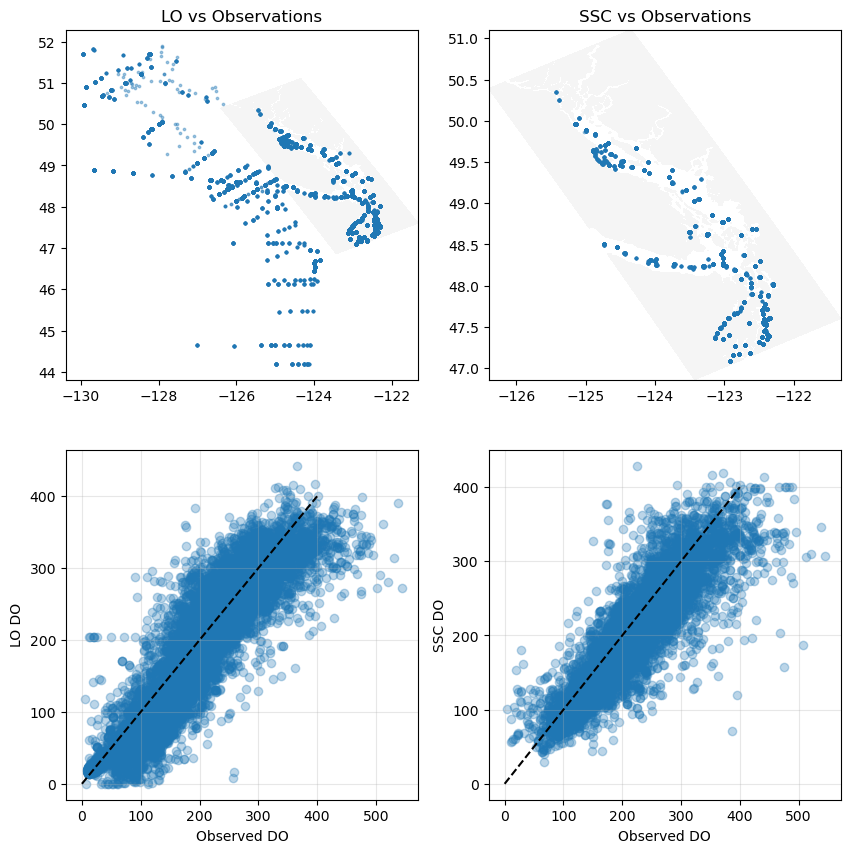

In [737]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
# map
domain_map(ax[0,0], obs_plot, mesh)
ax[0,0].set_title("LO vs Observations")

ax[1,0].scatter(obs_plot["DO_obs"], cas7_plot["DO_cas7"], alpha=0.3)
ax[1,0].plot([0, 400], [0, 400], 'k--')
ax[1,0].set_xlabel("Observed DO")
ax[1,0].set_ylabel("LO DO")
ax[1,0].grid(alpha=0.3)

domain_map(ax[0,1], ssc_plot, mesh)
ax[0,1].set_title("SSC vs Observations")

ax[1,1].scatter(ssc_plot["DO_obs"], ssc_plot["DO_ssc"], alpha=0.3)
ax[1,1].plot([0, 400], [0, 400], 'k--')
ax[1,1].set_xlabel("Observed DO")
ax[1,1].set_ylabel("SSC DO")
ax[1,1].grid(alpha=0.3)


### Generalize to all variables

In [738]:
# Build a unique key for each point (time + rounded lat/lon/z)
def make_key(df):
    return (
        df["time"].astype(str) + "_" +
        df["lat"].round(3).astype(str) + "_" +
        df["lon"].round(3).astype(str) + "_" +
        df["z"].round(0).astype(str)
    )

obs["key"]  = make_key(obs)
cas7["key"] = make_key(cas7)
ssc["key"]  = make_key(ssc)


In [739]:
# Keep only numeric columns for averaging
ssc_grouped = ssc.groupby("key").mean(numeric_only=True)

# Build final dataframe for comparison
df_final = obs.copy()

cas7_no_coords = cas7.drop(columns=["time", "lat", "lon", "z"])
df_final = df_final.join(cas7_no_coords, rsuffix="_cas7")

df_final = df_final.join(ssc_grouped, on="key", rsuffix="_ssc")


In [740]:
df_final.head()[:2]

,cid,lon,lat,time,z,SA,CT,DO_obs,NO3 (uM),Chl (mg m-3),...,mod_silicon,SSC_NH4,SSC_DIAT,SSC_FLAG,SSC_SA,SSC_CT,SSC_TA,SSC_DIC,DO_ssc,k
0,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-1.586481,29.971818,8.936296,228.198227,26.690001,NaN,...,42.154877,2.553482,0.330623,0.173576,28.457170,8.922669,2039.455811,1978.243286,227.280518,1.0
1,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-6.147543,29.960047,8.937135,228.198227,26.670000,NaN,...,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573,6.0


In [741]:
# Keep only common points (where SSC is not NaN)

mask = df_final["SSC_SA"].notna() 
df_common = df_final[mask].copy()

print("Total OBS points:", len(df_final))
print("Common points:", len(df_common))


Total OBS points: 22700
Common points: 15060


In [742]:
df_common.head()[:2]

,cid,lon,lat,time,z,SA,CT,DO_obs,NO3 (uM),Chl (mg m-3),...,mod_silicon,SSC_NH4,SSC_DIAT,SSC_FLAG,SSC_SA,SSC_CT,SSC_TA,SSC_DIC,DO_ssc,k
0,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-1.586481,29.971818,8.936296,228.198227,26.690001,NaN,...,42.154877,2.553482,0.330623,0.173576,28.457170,8.922669,2039.455811,1978.243286,227.280518,1.0
1,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-6.147543,29.960047,8.937135,228.198227,26.670000,NaN,...,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573,6.0


In [743]:
# Build separate dataframes for each dataset with only the common points
obs_common = df_common[obs.columns].copy()

cas7_cols = [c for c in df_common.columns if c.endswith("_cas7")]# or c.endswith(" (uM)") or c.endswith(" (mg m-3)")]
cas7_common = df_common[cas7_cols].copy()
cas7_common.columns = [c.replace("_cas7", "").replace(" (uM)", "").replace(" (mg m-3)", "") for c in cas7_common.columns]

ssc_cols = [c for c in df_common.columns if c.startswith("SSC_") or c.startswith("mod_") or c.startswith("DO_ssc")]
ssc_common = df_common[ssc_cols].copy()
ssc_common.columns = [c.replace("SSC_", "").replace("mod_", "").replace("DO_ssc", "DO") for c in ssc_common.columns]


In [744]:
# Add lat/lon/z/time back to cas7 and ssc for the common points to the beginning of the dataframe (for easier use later)
cas7_common = obs_common[["time", "lat", "lon", "z"]].join(cas7_common)
ssc_common = obs_common[["time", "lat", "lon", "z"]].join(ssc_common)
cas7_common[["time", "lat", "lon", "z"]] = obs_common[["time", "lat", "lon", "z"]]
ssc_common[["time", "lat", "lon", "z"]] = obs_common[["time", "lat", "lon", "z"]]

In [745]:
ssc_common.head()[:2]

,time,lat,lon,z,NO3,silicon,NH4,DIAT,FLAG,SA,CT,TA,DIC,DO
0,2015-02-11 05:17:46,48.613335,-123.243835,-1.586481,26.822687,42.154877,2.553482,0.330623,0.173576,28.457170,8.922669,2039.455811,1978.243286,227.280518
1,2015-02-11 05:17:46,48.613335,-123.243835,-6.147543,26.883862,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573


In [746]:
cas7_common.head()[:2]

,time,lat,lon,z,cid,cruise,name,source,CT,SA,DO,Chl,NO3,NH4,TA,DIC,key
0,2015-02-11 05:17:46,48.613335,-123.243835,-1.586481,0.0,None,None,dfo1,8.882023,29.319610,233.315201,0.321148,26.387203,0.113119,2090.811768,2040.690186,2015-02-11 05:17:46_48.613_-123.244_-2.0
1,2015-02-11 05:17:46,48.613335,-123.243835,-6.147543,0.0,None,None,dfo1,8.927380,29.926887,226.190674,0.227621,26.764687,0.118962,2124.303711,2073.917969,2015-02-11 05:17:46_48.613_-123.244_-6.0


In [747]:
obs_common.head()[:2]

,cid,lon,lat,time,z,SA,CT,DO_obs,NO3 (uM),Chl (mg m-3),name,cruise,source,NH4 (uM),PO4 (uM),SiO4 (uM),NO2 (uM),TA (uM),DIC (uM),key
0,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-1.586481,29.971818,8.936296,228.198227,26.690001,NaN,None,None,dfo1,NaN,NaN,NaN,NaN,NaN,NaN,2015-02-11 05:17:46_48.613_-123.244_-2.0
1,0.0,-123.243835,48.613335,2015-02-11 05:17:46,-6.147543,29.960047,8.937135,228.198227,26.670000,NaN,None,None,dfo1,NaN,NaN,NaN,NaN,NaN,NaN,2015-02-11 05:17:46_48.613_-123.244_-6.0


In [748]:
# Harmonize variable names
rename_map = {
    "DO_obs": "DO",
    "NO3 (uM)": "NO3",
    "NH4 (uM)": "NH4",
    "Chl (mg m-3)": "Chl",
    "DIC (uM)": "DIC",
    "TA (uM)": "TA"
}

obs_common  = obs_common.rename(columns=rename_map)
cas7_common = cas7_common.rename(columns=rename_map)


In [749]:
data_dict = {
    "obs": obs_common.reset_index(drop=True),
    "cas7_t1_x11ab": cas7_common.reset_index(drop=True),
    "ssc": ssc_common.reset_index(drop=True),
    "meta": {
        "n_points": len(df_common),
        "description": "Common OBS–LO–SSC aligned dataset",
    }
}
for key in ["obs", "cas7_t1_x11ab"]:
    data_dict[key] = data_dict[key].drop(columns=["key"])
if year_for_saving_data_properly is not None:
    output_path = Path(f"/ocean/atall/MOAD/ObsModel/ObsLOSSC/combined_bottle_{year_for_saving_data_properly}_cas7_t1_x11ab_ssc.p")
    pd.to_pickle(data_dict, output_path)

In [750]:
data_dict["ssc"].head()

,time,lat,lon,z,NO3,silicon,NH4,DIAT,FLAG,SA,CT,TA,DIC,DO
0,2015-02-11 05:17:46,48.613335,-123.243835,-1.586481,26.822687,42.154877,2.553482,0.330623,0.173576,28.457170,8.922669,2039.455811,1978.243286,227.280518
1,2015-02-11 05:17:46,48.613335,-123.243835,-6.147543,26.883862,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573
2,2015-02-11 05:17:46,48.613335,-123.243835,-6.147543,26.883862,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573
3,2015-02-11 05:17:46,48.613335,-123.243835,-6.147543,26.883862,41.631546,2.367164,0.291281,0.163162,29.120768,9.010991,2072.990723,2009.422241,224.124573
4,2015-02-11 05:17:46,48.613335,-123.243835,-11.303405,26.886709,41.426037,2.281241,0.270879,0.156861,29.382191,9.048499,2086.240479,2021.728760,222.839478


In [751]:
for k in ["obs", "cas7_t1_x11ab", "ssc"]:
    print(k, data_dict[k].shape)

print("OBS columns:", data_dict["obs"].columns)
print("LO columns:", data_dict["cas7_t1_x11ab"].columns)
print("SSC columns:", data_dict["ssc"].columns)

obs (15060, 19)
cas7_t1_x11ab (15060, 16)
ssc (15060, 14)
OBS columns: Index(['cid', 'lon', 'lat', 'time', 'z', 'SA', 'CT', 'DO', 'NO3', 'Chl',
       'name', 'cruise', 'source', 'NH4', 'PO4 (uM)', 'SiO4 (uM)', 'NO2 (uM)',
       'TA', 'DIC'],
      dtype='object')
LO columns: Index(['time', 'lat', 'lon', 'z', 'cid', 'cruise', 'name', 'source', 'CT',
       'SA', 'DO', 'Chl', 'NO3', 'NH4', 'TA', 'DIC'],
      dtype='object')
SSC columns: Index(['time', 'lat', 'lon', 'z', 'NO3', 'silicon', 'NH4', 'DIAT', 'FLAG',
       'SA', 'CT', 'TA', 'DIC', 'DO'],
      dtype='object')


In [752]:
def compute_metrics(obs, mod):
    mask = (~np.isnan(obs)) & (~np.isnan(mod))

    if mask.sum() < 10:
        return np.nan, np.nan, np.nan, np.nan, 0

    o = obs[mask]
    m = mod[mask]

    diff = m - o

    bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff**2))
    r2 = np.corrcoef(o, m)[0, 1] ** 2

    # Nash–Sutcliffe Efficiency
    denom = np.sum((o - o.mean())**2)
    nse = 1 - np.sum(diff**2) / denom if denom != 0 else np.nan

    return bias, rmse, r2, nse, mask.sum()

In [753]:
obs_df  = data_dict["obs"]
cas7_df = data_dict["cas7_t1_x11ab"]
ssc_df  = data_dict["ssc"]

# Variables present in ALL datasets
vars_common = sorted(set(obs_df.columns) & set(cas7_df.columns) & set(ssc_df.columns))

# Remove time/lat/lon/z and other
exclude = ["time", "lat", "lon", "z", "cid", "name", "cruise", "source"]
vars_common = [v for v in vars_common if v not in exclude]

print("Variables to be analyzed:", vars_common)

Variables to be analyzed: ['CT', 'DIC', 'DO', 'NH4', 'NO3', 'SA', 'TA']


In [754]:
rows = []

for var in vars_common:

    obs = obs_df[var].values
    cas7 = cas7_df[var].values
    ssc  = ssc_df[var].values

    b_c, r_c, r2_c, nse_c, n_c = compute_metrics(obs, cas7)
    b_s, r_s, r2_s, nse_s, n_s = compute_metrics(obs, ssc)

    rows.append({
        "Variable": var,

        "CAS7_bias": b_c,
        "CAS7_RMSE": r_c,
        "CAS7_R2": r2_c,
        "CAS7_NSE": nse_c,
        "CAS7_N": n_c,

        "SSC_bias": b_s,
        "SSC_RMSE": r_s,
        "SSC_R2": r2_s,
        "SSC_NSE": nse_s,
        "SSC_N": n_s,
    })

metrics_df = pd.DataFrame(rows)

In [755]:
metrics_df = metrics_df.sort_values("Variable")
print(metrics_df.round(3))

  Variable  CAS7_bias  CAS7_RMSE  CAS7_R2  CAS7_NSE  CAS7_N  SSC_bias  \
0       CT     -0.080      0.695    0.906     0.902   10734    -0.050   
1      DIC     54.684     78.879    0.833     0.677    1791   -45.659   
2       DO    -11.844     33.645    0.827     0.779   10548   -15.758   
3      NH4     -0.327      1.450    0.135     0.072    7613     2.494   
4      NO3      4.615      6.476    0.680     0.340   13408     1.854   
5       SA      0.548      1.020    0.864     0.809   10756    -0.163   
6       TA     35.198     51.142    0.872     0.747    1814    -0.609   

   SSC_RMSE  SSC_R2  SSC_NSE  SSC_N  
0     0.817   0.883    0.865  10734  
1    84.629   0.763    0.629   1791  
2    37.636   0.776    0.724  10548  
3     3.122   0.045   -3.304   7613  
4     5.189   0.655    0.576  13408  
5     1.067   0.836    0.791  10756  
6    41.165   0.839    0.836   1814  


/tmp/ipykernel_3661401/4107021184.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


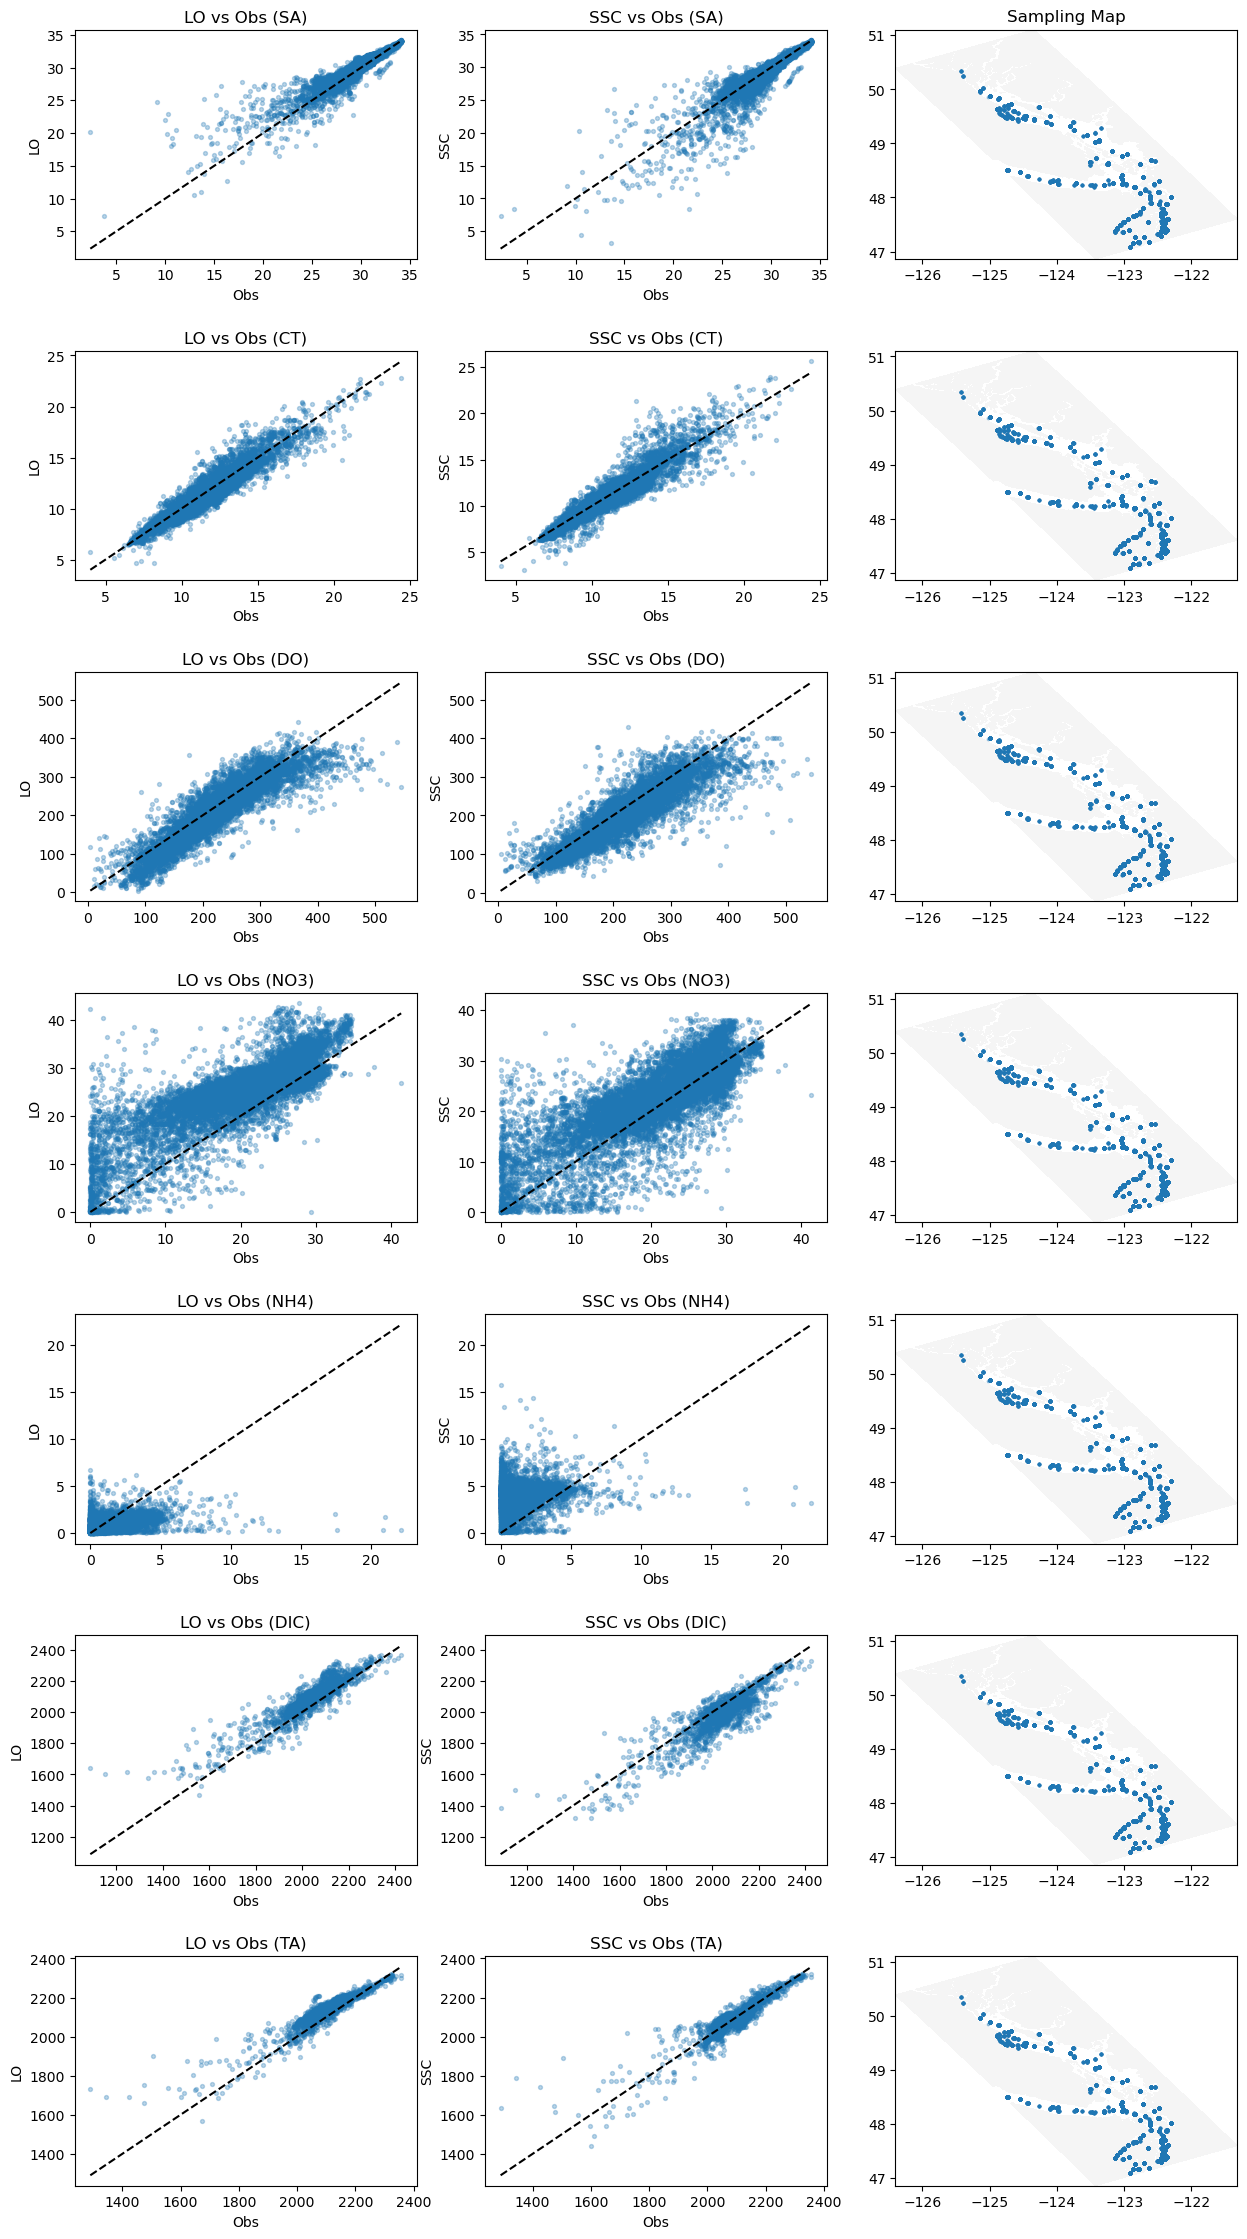

In [756]:
vars_common = ['SA', 'CT', 'DO', 'NO3', 'NH4', 'DIC', 'TA']

nvar = len(vars_common)

fig = plt.figure(figsize=(15, 4*nvar))
gs = gridspec.GridSpec(nvar, 3, width_ratios=[1,1,1], hspace=0.4)

for i, var in enumerate(vars_common):

    # Axes
    ax1 = fig.add_subplot(gs[i, 0])
    ax2 = fig.add_subplot(gs[i, 1])
    ax3 = fig.add_subplot(gs[i, 2])

    # LO vs OBS
    mask = (~np.isnan(obs_df[var])) & (~np.isnan(cas7_df[var]))

    ax1.scatter(
        obs_df[var][mask],
        cas7_df[var][mask],
        alpha=0.3,
        s=8
    )

    vmin = np.nanmin(obs_df[var][mask])
    vmax = np.nanmax(obs_df[var][mask])
    ax1.plot([vmin, vmax], [vmin, vmax], 'k--')

    ax1.set_title(f"LO vs Obs ({var})")
    ax1.set_xlabel("Obs")
    ax1.set_ylabel("LO")

    # SSC vs OBS
    mask = (~np.isnan(obs_df[var])) & (~np.isnan(ssc_df[var]))

    ax2.scatter(
        obs_df[var][mask],
        ssc_df[var][mask],
        alpha=0.3,
        s=8
    )

    vmin = np.nanmin(obs_df[var][mask])
    vmax = np.nanmax(obs_df[var][mask])
    ax2.plot([vmin, vmax], [vmin, vmax], 'k--')

    ax2.set_title(f"SSC vs Obs ({var})")
    ax2.set_xlabel("Obs")
    ax2.set_ylabel("SSC")

    # MAP 
    domain_map(ax3, obs_df, mesh)

    if i == 0:
        ax3.set_title("Sampling Map")

plt.tight_layout()
plt.show()

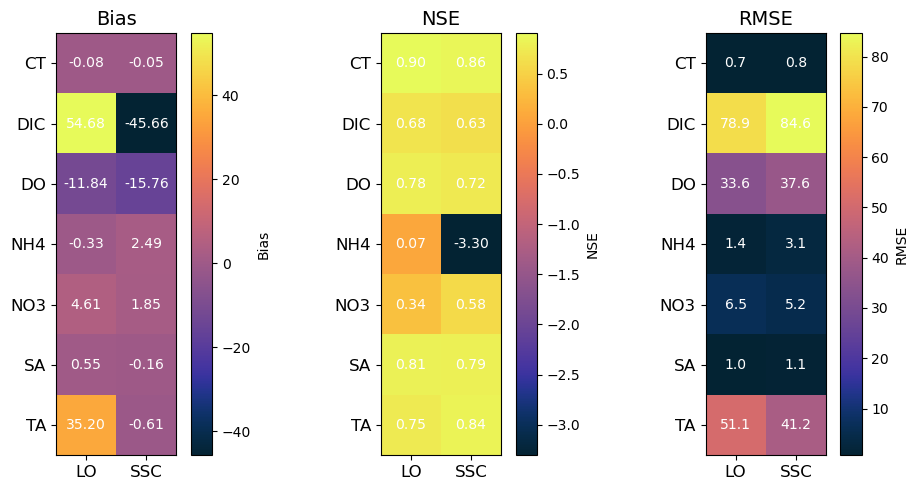

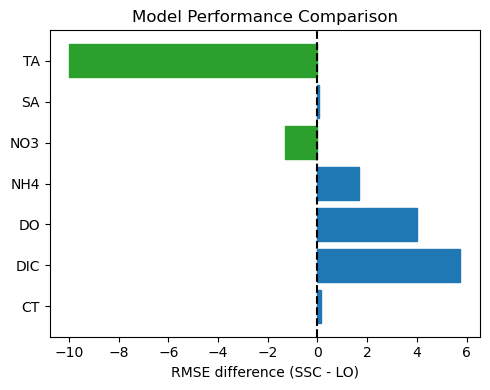

In [757]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
df_plot = metrics_df.copy()

########### Bias
data = df_plot[["CAS7_bias", "SSC_bias"]].values

im = ax[0].imshow(data, cmap=cm.thermal)

# Labels
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["LO", "SSC"], fontsize=12)

ax[0].set_yticks(np.arange(len(df_plot)))
ax[0].set_yticklabels(df_plot["Variable"], fontsize=12)

#ax[0].set_title("R²", fontsize=14)
ax[0].set_title("Bias", fontsize=14)

# Annotate values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax[0].text(j, i, f"{val:.2f}",
                       ha="center", va="center", color="white", fontsize=10)

plt.colorbar(im, ax=ax[0], label="Bias")


###### NSE
data = df_plot[["CAS7_NSE", "SSC_NSE"]].values

im2 = ax[1].imshow(data, cmap=cm.thermal)

ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["LO", "SSC"], fontsize=12)

ax[1].set_yticks(np.arange(len(df_plot)))
ax[1].set_yticklabels(df_plot["Variable"], fontsize=12)

ax[1].set_title("NSE", fontsize=14)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax[1].text(j, i, f"{val:.2f}",
                       ha="center", va="center", color="white", fontsize=10)

plt.colorbar(im2, ax=ax[1], label="NSE")


########### RMSE
data = df_plot[["CAS7_RMSE", "SSC_RMSE"]].values
im3 = ax[2].imshow(data, cmap=cm.thermal)

ax[2].set_xticks([0, 1])
ax[2].set_xticklabels(["LO", "SSC"], fontsize=12)

ax[2].set_yticks(np.arange(len(df_plot)))
ax[2].set_yticklabels(df_plot["Variable"], fontsize=12)

ax[2].set_title("RMSE", fontsize=14)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax[2].text(j, i, f"{val:.1f}",
                       ha="center", va="center", color="white", fontsize=10)

plt.colorbar(im3, ax=ax[2], label="RMSE")
plt.tight_layout()
plt.show()

#################################################################
def best_model(row):
    if np.isnan(row["CAS7_RMSE"]) or np.isnan(row["SSC_RMSE"]):
        return np.nan
    return "SSC" if row["SSC_RMSE"] < row["CAS7_RMSE"] else "CAS7"

df_plot["Best_Model"] = df_plot.apply(best_model, axis=1)

fig, ax = plt.subplots(figsize=(5, 4))

y = np.arange(len(df_plot))

# RMSE difference (SSC - LO)
diff = df_plot["SSC_RMSE"] - df_plot["CAS7_RMSE"]

bars = ax.barh(y, diff)

# Color by winner
for i, b in enumerate(bars):
    if diff.iloc[i] < 0:
        b.set_color("tab:green")  # SSC better
    else:
        b.set_color("tab:blue")   # LO better

ax.set_yticks(y)
ax.set_yticklabels(df_plot["Variable"])

ax.axvline(0, linestyle="--", color="k")

ax.set_xlabel("RMSE difference (SSC - LO)")
ax.set_title("Model Performance Comparison")

plt.tight_layout()
plt.show()